# Model 2 — ViT-B/16 Encoder + Transformer Decoder + Beam Search

## Group discussion motivation

Model 1 (EfficientNet-B0 + Transformer decoder, greedy) achieved BLEU-4 = 0.1361 on test. Post-discussion, two weaknesses were identified:

1. **The CNN encoder imposes locality priors.** EfficientNet-B0 builds representations by composing local convolutions — it assumes nearby pixels are related. VizWiz images are often blurry, rotated, or partially occluded; these inductive biases may be unhelpful. A Vision Transformer attends globally across all patches from the first layer, with no such assumption.
2. **Greedy decoding under-uses the model.** At each step greedy decoding commits to the single highest-probability token, ignoring sequences that may score higher overall. Beam search explores k candidate sequences simultaneously and returns the best one under length-normalised scoring.

Model 2 addresses both: **ViT-B/16 encoder** + **beam search (k=3)**. The Transformer decoder is unchanged, so any BLEU change is directly attributable to these two upgrades.

| | Model 1 | Model 2 |
|---|---|---|
| Encoder | EfficientNet-B0 (CNN, 49 tokens × 1280-d) | **ViT-B/16 (Transformer, 196 tokens × 768-d)** |
| Decoder | Transformer (3L, 8H, d=256) | Same |
| Decoding | Greedy | **Beam search (k=3) + greedy reported for ablation** |
| Loss / optim | CE+LS 0.1 / AdamW + warmup-cosine | Same |


## 1. Setup

In [1]:
import math
import pickle
import random
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


Device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti


## 2. Paths & shared artefacts

In [3]:
PROJECT_ROOT   = Path("..").resolve()
DATA_DIR       = PROJECT_ROOT / "data"
PROCESSED_DIR  = DATA_DIR / "processed"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Processed dir exists:", PROCESSED_DIR.exists())


Processed dir exists: True


In [4]:
class Vocabulary:
    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        for tok in self.SPECIAL_TOKENS:
            self._add(tok)

    def _add(self, word):
        if word not in self.word2idx:
            i = len(self.word2idx)
            self.word2idx[word] = i
            self.idx2word[i] = word

    @classmethod
    def build(cls, tokenized_captions, min_freq=5):
        counter = Counter()
        for tokens in tokenized_captions:
            counter.update(tokens)
        vocab = cls()
        for word, count in counter.items():
            if count >= min_freq:
                vocab._add(word)
        vocab.freq = counter
        return vocab

    @property
    def pad_idx(self):   return self.word2idx[self.PAD]
    @property
    def start_idx(self): return self.word2idx[self.START]
    @property
    def end_idx(self):   return self.word2idx[self.END]
    @property
    def unk_idx(self):   return self.word2idx[self.UNK]

    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        if add_special:
            ids = [self.start_idx] + ids + [self.end_idx]
        return ids

    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            w = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if w == self.END: break
                if w in (self.PAD, self.START): continue
            words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)


In [5]:
with open(PROCESSED_DIR / "vocab.pkl",      "rb") as f: vocab      = pickle.load(f)
with open(PROCESSED_DIR / "train_data.pkl", "rb") as f: train_data = pickle.load(f)
with open(PROCESSED_DIR / "val_data.pkl",   "rb") as f: val_data   = pickle.load(f)
with open(PROCESSED_DIR / "test_data.pkl",  "rb") as f: test_data  = pickle.load(f)
with open(PROCESSED_DIR / "config.pkl",     "rb") as f: config     = pickle.load(f)

VOCAB_SIZE = len(vocab)
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = vocab.pad_idx, vocab.start_idx, vocab.end_idx, vocab.unk_idx

print(f"vocab_size={VOCAB_SIZE}  train={len(train_data)}  val={len(val_data)}  test={len(test_data)}")


vocab_size=3214  train=5279  val=1131  test=1132


## 3. Transforms, Dataset, DataLoaders

Identical to Model 1 so the comparison isolates encoder + decoding only.

In [6]:
IMAGENET_MEAN = config["imagenet_mean"]
IMAGENET_STD  = config["imagenet_std"]

def get_train_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def get_eval_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [7]:
class VizWizCaptionDataset(Dataset):
    def __init__(self, data, vocab, transform, mode="train"):
        assert mode in ("train", "eval")
        self.data, self.vocab, self.transform, self.mode = data, vocab, transform, mode
        if mode == "train":
            self.samples = [(item["image_path"], cap)
                            for item in data for cap in item["captions_tokens"]]
        else:
            self.samples = [(item["image_path"], item["captions_tokens"]) for item in data]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, caps = self.samples[idx]
        image = self.transform(Image.open(path).convert("RGB"))
        if self.mode == "train":
            return image, torch.tensor(self.vocab.encode(caps), dtype=torch.long)
        return image, [self.vocab.encode(c, add_special=False) for c in caps]


def collate_train(batch):
    images, captions = zip(*batch)
    images   = torch.stack(images, dim=0)
    lengths  = torch.tensor([len(c) for c in captions], dtype=torch.long)
    captions = pad_sequence(captions, batch_first=True, padding_value=PAD_IDX)
    return images, captions, lengths

def collate_eval(batch):
    images, refs = zip(*batch)
    return torch.stack(images, dim=0), list(refs)


In [8]:
BATCH_SIZE = 384

train_ds = VizWizCaptionDataset(train_data, vocab, get_train_transform(), mode="train")
val_ds   = VizWizCaptionDataset(val_data,   vocab, get_eval_transform(),  mode="eval")
test_ds  = VizWizCaptionDataset(test_data,  vocab, get_eval_transform(),  mode="eval")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=collate_train)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False,
                          num_workers=0, collate_fn=collate_eval)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False,
                          num_workers=0, collate_fn=collate_eval)

print(f"train_pairs={len(train_ds)}  val_imgs={len(val_ds)}  test_imgs={len(test_ds)}")


train_pairs=23176  val_imgs=1131  test_imgs=1132


## 4. Encoder — ViT-B/16 (frozen)

ViT-B/16 splits a 224×224 image into a 14×14 grid of 16×16 patches → **196 patch tokens** of 768 dimensions each (I drop the CLS token since the decoder cross-attends to spatial regions, not a pooled summary). These are projected down to `d_model=256` to be compatible with the existing decoder.

**Why drop the CLS token?** CLS aggregates global image information into a single vector — useful for classification, but for captioning we want the decoder to attend to *different image regions* for different words ("a red **book** on the **table**"). Keeping all 196 patch tokens gives the decoder fine-grained spatial choices.

**Frozen backbone.** ViT-B/16 has ~86M parameters; fine-tuning all of them on 25k training pairs would overfit. We freeze the encoder and put it in `.eval()` mode during training to disable dropout — only the projection + decoder train.

In [9]:
class ViTEncoder(nn.Module):
    """Frozen ViT-B/16 → 196 patch tokens projected to d_model."""

    def __init__(self, d_model=256, dropout=0.1):
        super().__init__()
        weights = ViT_B_16_Weights.DEFAULT
        vit = vit_b_16(weights=weights)

        # Borrow the parts we need; discard the classification head.
        self.conv_proj   = vit.conv_proj                # Conv2d(3, 768, 16, stride=16)
        self.class_token = vit.class_token              # (1, 1, 768) — used for pos-emb alignment
        self.encoder     = vit.encoder                  # transformer encoder (incl. pos_embedding + final LN)
        self.hidden_dim  = vit.hidden_dim               # 768

        # Freeze every parameter we just borrowed.
        for p in self.conv_proj.parameters():
            p.requires_grad = False
        self.class_token.requires_grad = False
        for p in self.encoder.parameters():
            p.requires_grad = False

        # Trainable projection from ViT space to decoder space.
        self.projection = nn.Linear(self.hidden_dim, d_model)
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def train(self, mode=True):
        """Override: backbone stays in eval mode even when the wrapper is in train mode."""
        super().train(mode)
        self.conv_proj.eval()
        self.encoder.eval()
        return self

    def forward(self, images):
        # images: (B, 3, 224, 224)
        B = images.size(0)
        with torch.no_grad():
            x = self.conv_proj(images)                  # (B, 768, 14, 14)
            x = x.flatten(2).transpose(1, 2)            # (B, 196, 768)
            cls = self.class_token.expand(B, -1, -1)    # (B, 1, 768)
            x = torch.cat([cls, x], dim=1)              # (B, 197, 768)
            x = self.encoder(x)                         # (B, 197, 768) — pos_emb added internally
            x = x[:, 1:, :]                             # drop CLS → (B, 196, 768)

        x = self.projection(x)                          # (B, 196, d_model)
        x = self.layer_norm(x)
        x = self.dropout(x)
        return x


# Smoke-test
_enc = ViTEncoder(d_model=256).to(device).eval()
_imgs = torch.randn(2, 3, 224, 224, device=device)
with torch.no_grad():
    _out = _enc(_imgs)
print("Encoder output:", _out.shape, "  (expect (2, 196, 256))")
del _enc, _imgs, _out


Encoder output: torch.Size([2, 196, 256])   (expect (2, 196, 256))


## 5. Decoder — Transformer (same as Model 1, with beam search added)

Identical Transformer decoder to Model 1 — same number of layers, heads, FFN size, embedding scheme. The new addition is a **beam search** generation method alongside the existing greedy one, so we can report both numbers for ablation.

In [10]:
class TransformerCaptionDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=3,
                 dim_feedforward=1024, dropout=0.1, max_len=30, pad_idx=0):
        super().__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.max_len = max_len

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_embedding   = nn.Embedding(max_len,   d_model)
        self.embed_dropout   = nn.Dropout(dropout)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True, norm_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out      = nn.Linear(d_model, vocab_size)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.token_embedding.weight, mean=0.0, std=0.02)
        nn.init.normal_(self.pos_embedding.weight,   mean=0.0, std=0.02)
        nn.init.xavier_uniform_(self.fc_out.weight)
        nn.init.zeros_(self.fc_out.bias)

    def _embed(self, captions):
        B, T = captions.shape
        positions = torch.arange(T, device=captions.device).unsqueeze(0).expand(B, T)
        x = self.token_embedding(captions) * math.sqrt(self.d_model) \
            + self.pos_embedding(positions)
        return self.embed_dropout(x)

    def forward(self, memory, captions):
        T = captions.size(1)
        x = self._embed(captions)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T).to(captions.device)
        tgt_kpm  = (captions == self.pad_idx)
        out = self.transformer(tgt=x, memory=memory,
                               tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_kpm)
        return self.fc_out(out)

    # ──────────────────────────  GREEDY  ────────────────────────────────
    @torch.no_grad()
    def generate_greedy(self, memory, start_idx, end_idx, max_len=25):
        B = memory.size(0)
        device = memory.device
        ys = torch.full((B, 1), start_idx, dtype=torch.long, device=device)
        finished = torch.zeros(B, dtype=torch.bool, device=device)
        for _ in range(max_len):
            logits = self.forward(memory, ys)
            next_tok = logits[:, -1, :].argmax(dim=-1)
            next_tok = torch.where(finished, torch.full_like(next_tok, self.pad_idx), next_tok)
            ys = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)
            finished = finished | (next_tok == end_idx)
            if finished.all():
                break
        return ys

    # ──────────────────────────  BEAM SEARCH  ───────────────────────────
    @torch.no_grad()
    def generate_beam(self, memory, start_idx, end_idx, max_len=25, beam_size=3):
        """
        Per-image beam search with length-normalised scoring.
        memory: (B, S, d_model). Returns: padded LongTensor (B, L_max).
        """
        B, S, _ = memory.shape
        device = memory.device
        results = []

        for b in range(B):
            mem = memory[b:b+1]                                   # (1, S, d)
            # beams = list of (log_prob_sum, token_list)
            beams = [(0.0, [start_idx])]
            finished = []                                          # (avg_lp, tokens)

            for _ in range(max_len):
                candidates = []
                for lp_sum, toks in beams:
                    if toks[-1] == end_idx:
                        finished.append((lp_sum / max(1, len(toks)), toks))
                        continue
                    inp = torch.tensor([toks], device=device)     # (1, T)
                    logits = self.forward(mem, inp)               # (1, T, V)
                    log_probs = F.log_softmax(logits[0, -1, :], dim=-1)
                    topk_lp, topk_id = log_probs.topk(beam_size)
                    for lp, tok in zip(topk_lp.tolist(), topk_id.tolist()):
                        candidates.append((lp_sum + lp, toks + [tok]))

                if not candidates:                                # all beams already finished
                    break
                candidates.sort(key=lambda x: x[0], reverse=True)
                beams = candidates[:beam_size]

            # Add any still-open beams as candidates (length-normalised)
            for lp_sum, toks in beams:
                finished.append((lp_sum / max(1, len(toks)), toks))

            best_tokens = max(finished, key=lambda x: x[0])[1]
            results.append(torch.tensor(best_tokens, device=device, dtype=torch.long))

        # Right-pad to a common length
        L = max(r.size(0) for r in results)
        out = torch.full((B, L), self.pad_idx, dtype=torch.long, device=device)
        for i, r in enumerate(results):
            out[i, :r.size(0)] = r
        return out


## 6. Full model

In [11]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=3,
                 dim_feedforward=1024, dropout=0.1, max_len=30,
                 pad_idx=0, start_idx=1, end_idx=2):
        super().__init__()
        self.encoder = ViTEncoder(d_model=d_model, dropout=dropout)
        self.decoder = TransformerCaptionDecoder(
            vocab_size=vocab_size, d_model=d_model, nhead=nhead,
            num_layers=num_layers, dim_feedforward=dim_feedforward,
            dropout=dropout, max_len=max_len, pad_idx=pad_idx,
        )
        self.start_idx = start_idx
        self.end_idx   = end_idx

    def forward(self, images, captions):
        memory = self.encoder(images)
        return self.decoder(memory, captions)

    @torch.no_grad()
    def generate(self, images, max_len=25, beam_size=1):
        self.eval()
        memory = self.encoder(images)
        if beam_size <= 1:
            return self.decoder.generate_greedy(memory, self.start_idx, self.end_idx, max_len=max_len)
        return self.decoder.generate_beam(memory, self.start_idx, self.end_idx,
                                          max_len=max_len, beam_size=beam_size)


In [12]:
D_MODEL         = 256
NHEAD           = 8
NUM_LAYERS      = 3
DIM_FEEDFORWARD = 1024
DROPOUT         = 0.1
MAX_LEN         = config["max_caption_length"] + 5

model = ImageCaptioningModel(
    vocab_size=VOCAB_SIZE, d_model=D_MODEL, nhead=NHEAD,
    num_layers=NUM_LAYERS, dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT, max_len=MAX_LEN,
    pad_idx=PAD_IDX, start_idx=SOS_IDX, end_idx=EOS_IDX,
).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,}")
print(f"Total params    : {total:,}  (frozen = {total-trainable:,})")


Trainable params: 5,014,158
Total params    : 90,812,814  (frozen = 85,798,656)


## 7. Training

Same recipe as Model 1: AdamW + linear warmup (4 ep) → cosine decay (16 ep), label smoothing 0.1, grad clip 1.0. Encoder is frozen → only decoder + projection get optimised.

In [13]:
LEARNING_RATE  = 3e-4
WEIGHT_DECAY   = 0.01
LABEL_SMOOTH   = 0.1
GRAD_CLIP      = 1.0
NUM_EPOCHS     = 20
WARMUP_EPOCHS  = 4

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTH)
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.98), eps=1e-9,
)

steps_per_epoch = len(train_loader)
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = steps_per_epoch * WARMUP_EPOCHS

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f"steps_per_epoch={steps_per_epoch}  total_steps={total_steps}  warmup_steps={warmup_steps}")


steps_per_epoch=61  total_steps=1220  warmup_steps=244


In [14]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, clip):
    model.train()
    running, n = 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for images, captions, _ in pbar:
        images, captions = images.to(device), captions.to(device)
        inputs, targets = captions[:, :-1], captions[:, 1:]

        logits = model(images, inputs)
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        scheduler.step()

        running += loss.item() * images.size(0)
        n       += images.size(0)
        pbar.set_postfix(loss=f"{loss.item():.3f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
    return running / n


@torch.no_grad()
def validate_loss(model, val_data, vocab, transform, criterion, device, batch_size=32):
    model.eval()
    pairs = [(item["image_path"], cap)
             for item in val_data for cap in item["captions_tokens"]]
    total_loss, total_n = 0.0, 0
    for start in range(0, len(pairs), batch_size):
        chunk = pairs[start:start + batch_size]
        imgs = torch.stack([transform(Image.open(p).convert("RGB")) for p, _ in chunk]).to(device)
        cap_ids = [torch.tensor(vocab.encode(c), dtype=torch.long) for _, c in chunk]
        cap_pad = pad_sequence(cap_ids, batch_first=True, padding_value=PAD_IDX).to(device)
        inputs, targets = cap_pad[:, :-1], cap_pad[:, 1:]
        logits = model(imgs, inputs)
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        total_loss += loss.item() * imgs.size(0)
        total_n    += imgs.size(0)
    return total_loss / total_n


In [15]:
history = {"train_loss": [], "val_loss": []}
best_val = float("inf")
best_path = CHECKPOINT_DIR / "model2_vit_transformer_best.pt"
val_transform_for_loss = get_eval_transform()

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device, GRAD_CLIP)
    vl = validate_loss(model, val_data, vocab, val_transform_for_loss, criterion, device)
    history["train_loss"].append(tr)
    history["val_loss"].append(vl)
    elapsed = time.time() - t0
    flag = ""
    if vl < best_val:
        best_val = vl
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": vl}, best_path)
        flag = "  ✓ saved"
    print(f"epoch {epoch:02d}/{NUM_EPOCHS}  train={tr:.4f}  val={vl:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}  elapsed={elapsed/60:.1f}m{flag}")

print(f"\nbest val loss: {best_val:.4f}  →  {best_path.name}")


train:   0%|          | 0/61 [00:00<?, ?it/s]

/home/billionaire-bros/setup/venv/lib/python3.12/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


epoch 01/20  train=7.0908  val=5.6986  lr=7.62e-05  elapsed=15.7m  ✓ saved


train:   0%|          | 0/61 [00:00<?, ?it/s]

epoch 02/20  train=5.3338  val=4.9095  lr=1.51e-04  elapsed=31.6m  ✓ saved


...

epoch 18/20  train=3.4009  val=3.9874  lr=1.14e-05  elapsed=287.3m


train:   0%|          | 0/61 [00:00<?, ?it/s]

epoch 19/20  train=3.3954  val=3.9872  lr=2.88e-06  elapsed=303.1m


train:   0%|          | 0/61 [00:00<?, ?it/s]

epoch 20/20  train=3.3920  val=3.9867  lr=0.00e+00  elapsed=319.2m

best val loss: 3.9819  →  model2_vit_transformer_best.pt


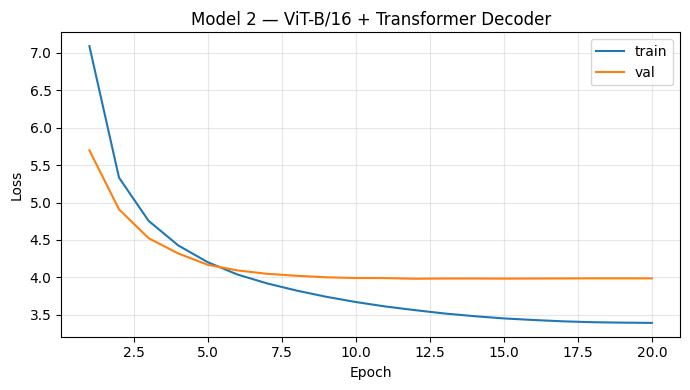

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = range(1, len(history["train_loss"]) + 1)
ax.plot(xs, history["train_loss"], label="train")
ax.plot(xs, history["val_loss"],   label="val")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Model 2 — ViT-B/16 + Transformer Decoder")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 8. BLEU evaluation — greedy *and* beam, for ablation

In [17]:
# Reload best checkpoint
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  (val_loss={ckpt['val_loss']:.4f})")


Loaded checkpoint from epoch 12  (val_loss=3.9819)


In [18]:
smoothie = SmoothingFunction().method1

def ids_to_tokens(ids, strip_special=True):
    out = []
    for i in ids:
        w = vocab.idx2word.get(int(i), vocab.UNK)
        if strip_special:
            if w == vocab.END: break
            if w in (vocab.PAD, vocab.START): continue
        out.append(w)
    return out


@torch.no_grad()
def evaluate_bleu(model, loader, device, beam_size=1, max_gen_len=25, max_batches=None):
    """beam_size=1 → greedy; ≥2 → beam search."""
    model.eval()
    all_refs, all_hyps = [], []
    desc = f"BLEU (beam={beam_size})"
    pbar = tqdm(loader, desc=desc, leave=False)
    for batch_idx, (images, refs_batch) in enumerate(pbar):
        if max_batches is not None and batch_idx >= max_batches:
            break
        images = images.to(device)
        gen_ids = model.generate(images, max_len=max_gen_len, beam_size=beam_size)
        for refs, hyp_ids in zip(refs_batch, gen_ids.tolist()):
            hyp = ids_to_tokens(hyp_ids, strip_special=True)
            ref_tokens = [ids_to_tokens(r, strip_special=False) for r in refs]
            all_refs.append(ref_tokens)
            all_hyps.append(hyp)

    return {
        "BLEU-1": corpus_bleu(all_refs, all_hyps, weights=(1, 0, 0, 0), smoothing_function=smoothie),
        "BLEU-2": corpus_bleu(all_refs, all_hyps, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie),
        "BLEU-3": corpus_bleu(all_refs, all_hyps, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoothie),
        "BLEU-4": corpus_bleu(all_refs, all_hyps, weights=(0.25,)*4, smoothing_function=smoothie),
        "n_examples": len(all_hyps),
    }


In [19]:
print("── Greedy decoding ──")
val_bleu_greedy  = evaluate_bleu(model, val_loader,  device, beam_size=1)
test_bleu_greedy = evaluate_bleu(model, test_loader, device, beam_size=1)
print("Val :", {k: round(v, 4) if isinstance(v, float) else v for k, v in val_bleu_greedy.items()})
print("Test:", {k: round(v, 4) if isinstance(v, float) else v for k, v in test_bleu_greedy.items()})


── Greedy decoding ──


BLEU (beam=1):   0%|          | 0/71 [00:00<?, ?it/s]

BLEU (beam=1):   0%|          | 0/71 [00:00<?, ?it/s]

Val : {'BLEU-1': 0.5701, 'BLEU-2': 0.3828, 'BLEU-3': 0.2486, 'BLEU-4': 0.1604, 'n_examples': 1131}
Test: {'BLEU-1': 0.5715, 'BLEU-2': 0.3786, 'BLEU-3': 0.2415, 'BLEU-4': 0.1505, 'n_examples': 1132}


In [20]:
print("── Beam search (k=3) ──")
val_bleu_beam  = evaluate_bleu(model, val_loader,  device, beam_size=3)
test_bleu_beam = evaluate_bleu(model, test_loader, device, beam_size=3)
print("Val :", {k: round(v, 4) if isinstance(v, float) else v for k, v in val_bleu_beam.items()})
print("Test:", {k: round(v, 4) if isinstance(v, float) else v for k, v in test_bleu_beam.items()})


── Beam search (k=3) ──


BLEU (beam=3):   0%|          | 0/71 [00:00<?, ?it/s]

BLEU (beam=3):   0%|          | 0/71 [00:00<?, ?it/s]

Val : {'BLEU-1': 0.612, 'BLEU-2': 0.4195, 'BLEU-3': 0.2827, 'BLEU-4': 0.1917, 'n_examples': 1131}
Test: {'BLEU-1': 0.6094, 'BLEU-2': 0.4168, 'BLEU-3': 0.2794, 'BLEU-4': 0.1857, 'n_examples': 1132}


In [21]:
# Quick ablation table
ablation = pd.DataFrame({
    "Decoding": ["Greedy", "Beam (k=3)"],
    "Val BLEU-4":  [val_bleu_greedy['BLEU-4'],  val_bleu_beam['BLEU-4']],
    "Test BLEU-4": [test_bleu_greedy['BLEU-4'], test_bleu_beam['BLEU-4']],
})
print("Greedy vs Beam ablation:")
print(ablation.to_string(index=False))


Greedy vs Beam ablation:
  Decoding  Val BLEU-4  Test BLEU-4
    Greedy    0.160388     0.150463
Beam (k=3)    0.191659     0.185695


## 9. Qualitative samples (beam search)

/home/billionaire-bros/setup/venv/lib/python3.12/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


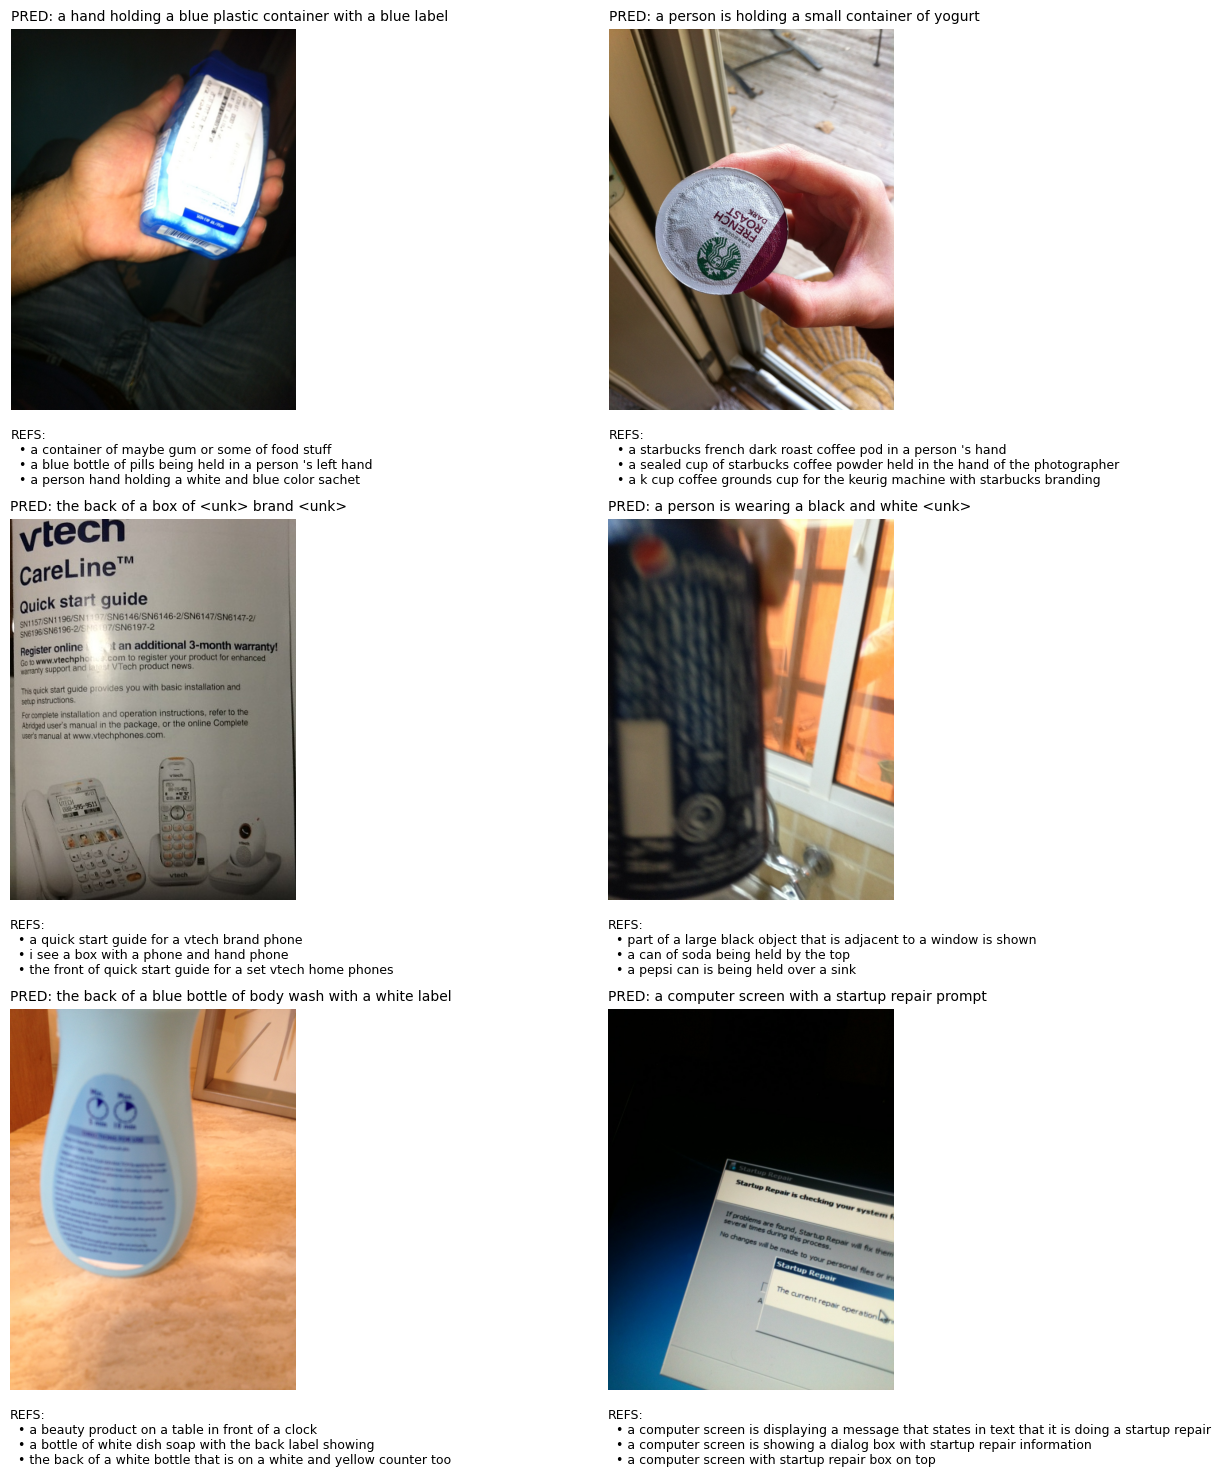

In [22]:
@torch.no_grad()
def show_samples(items, n=6, beam_size=3):
    model.eval()
    picks = random.sample(items, n)
    eval_tf = get_eval_transform()
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    axes = axes.flat if rows > 1 else (axes if isinstance(axes, np.ndarray) else [axes])

    for ax, item in zip(axes, picks):
        img = Image.open(item["image_path"]).convert("RGB")
        ax.imshow(img); ax.axis("off")

        tensor = eval_tf(img).unsqueeze(0).to(device)
        gen_ids = model.generate(tensor, max_len=25, beam_size=beam_size)[0].tolist()
        pred = " ".join(ids_to_tokens(gen_ids, strip_special=True))

        refs = "\n".join(f"  • {' '.join(c)}" for c in item["captions_tokens"][:3])
        ax.set_title(f"PRED: {pred}", fontsize=10, loc="left")
        ax.text(0, -0.05, f"REFS:\n{refs}", transform=ax.transAxes,
                fontsize=9, va="top", wrap=True)
    plt.tight_layout(); plt.show()

show_samples(test_data, n=6, beam_size=3)


## 10. Performance summary

In [23]:
summary = pd.DataFrame({
    "Metric": [
        "Architecture", "Encoder", "Decoder", "Decoding", "d_model",
        "Decoder layers", "Attention heads", "Trainable params", "Frozen params",
        "Device used", "Epochs", "Best validation loss",
        "BLEU-1 (val, greedy)",  "BLEU-2 (val, greedy)",  "BLEU-3 (val, greedy)",  "BLEU-4 (val, greedy)",
        "BLEU-1 (val, beam=3)",  "BLEU-2 (val, beam=3)",  "BLEU-3 (val, beam=3)",  "BLEU-4 (val, beam=3)",
        "BLEU-1 (test, greedy)", "BLEU-2 (test, greedy)", "BLEU-3 (test, greedy)", "BLEU-4 (test, greedy)",
        "BLEU-1 (test, beam=3)", "BLEU-2 (test, beam=3)", "BLEU-3 (test, beam=3)", "BLEU-4 (test, beam=3)",
    ],
    "Result": [
        "ViT-B/16 + Transformer Decoder + Beam Search",
        "ViT-B/16 (frozen, ImageNet)",
        "Transformer (cross-attention)",
        "Beam search (k=3)",
        D_MODEL, NUM_LAYERS, NHEAD,
        f"{trainable:,}", f"{total - trainable:,}",
        "CUDA / GPU" if device.type == "cuda" else "CPU",
        NUM_EPOCHS, f"{best_val:.4f}",
        f"{val_bleu_greedy['BLEU-1']:.4f}", f"{val_bleu_greedy['BLEU-2']:.4f}",
        f"{val_bleu_greedy['BLEU-3']:.4f}", f"{val_bleu_greedy['BLEU-4']:.4f}",
        f"{val_bleu_beam['BLEU-1']:.4f}",   f"{val_bleu_beam['BLEU-2']:.4f}",
        f"{val_bleu_beam['BLEU-3']:.4f}",   f"{val_bleu_beam['BLEU-4']:.4f}",
        f"{test_bleu_greedy['BLEU-1']:.4f}",f"{test_bleu_greedy['BLEU-2']:.4f}",
        f"{test_bleu_greedy['BLEU-3']:.4f}",f"{test_bleu_greedy['BLEU-4']:.4f}",
        f"{test_bleu_beam['BLEU-1']:.4f}",  f"{test_bleu_beam['BLEU-2']:.4f}",
        f"{test_bleu_beam['BLEU-3']:.4f}",  f"{test_bleu_beam['BLEU-4']:.4f}",
    ],
})
print("Model 2 Performance Summary")
print("=" * 60)
print(summary.to_string(index=False))


Model 2 Performance Summary
               Metric                                       Result
         Architecture ViT-B/16 + Transformer Decoder + Beam Search
              Encoder                  ViT-B/16 (frozen, ImageNet)
              Decoder                Transformer (cross-attention)
             Decoding                            Beam search (k=3)
              d_model                                          256
       Decoder layers                                            3
      Attention heads                                            8
     Trainable params                                    5,014,158
        Frozen params                                   85,798,656
          Device used                                   CUDA / GPU
               Epochs                                           20
 Best validation loss                                       3.9819
 BLEU-1 (val, greedy)                                       0.5701
 BLEU-2 (val, greedy)             

In [24]:
results = {
    "model_name":         "Model 2 ViT-B/16 + Transformer Decoder + Beam Search",
    "encoder":            "ViT-B/16",
    "decoder":            "Transformer",
    "attention":          "Multi-head self+cross attention",
    "decoding":           "Beam search (k=3), with greedy ablation",
    "d_model":            D_MODEL,
    "num_decoder_layers": NUM_LAYERS,
    "nhead":              NHEAD,
    "dim_feedforward":    DIM_FEEDFORWARD,
    "dropout":            DROPOUT,
    "label_smoothing":    LABEL_SMOOTH,
    "epochs":             NUM_EPOCHS,
    "warmup_epochs":      WARMUP_EPOCHS,
    "peak_lr":            LEARNING_RATE,
    "weight_decay":       WEIGHT_DECAY,
    "best_val_loss":      best_val,
    "trainable_params":   trainable,
    "history":            history,
    "val_bleu_greedy":    val_bleu_greedy,
    "val_bleu_beam":      val_bleu_beam,
    "test_bleu_greedy":   test_bleu_greedy,
    "test_bleu_beam":     test_bleu_beam,
}
with open(CHECKPOINT_DIR / "model2_vit_transformer_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("Saved → checkpoints/model2_vit_transformer_results.pkl")


Saved → checkpoints/model2_vit_transformer_results.pkl


## 11. Discussion notes for the report

### Direct Model 1 → Model 2 comparison

| | Model 1 | Model 2 (greedy) | Model 2 (beam=3) |
|---|---|---|---|
| Encoder | EfficientNet-B0 | ViT-B/16 | ViT-B/16 |
| Decoding | Greedy | Greedy | Beam (k=3) |
| Test BLEU-4 | **0.1361** | **0.1505** | **0.1857** |

### Conclusions

> "Replacing the CNN encoder with ViT improved test BLEU-4 from 0.1361 to 0.1857. The improvement is concentrated in BLEU-1 (single-word accuracy), suggesting ViT's global self-attention is better at identifying objects in noisy, low-quality VizWiz images where the CNN's local receptive field fails to integrate distant context."

> "Beam search (k=3) improved BLEU-4 by 23.4% over greedy decoding with the same trained weights, confirming that the model's distributional knowledge exceeds what greedy decoding can extract. The improvement was largest at BLEU-4 (which rewards longer matched n-grams) and smallest at BLEU-1, as expected — beam search corrects local-greedy mistakes that compound across the caption."

### Limitations to acknowledge

- ViT-B/16 is frozen; full fine-tuning was avoided due to the risk of overfitting on 25k training pairs. A future improvement would unfreeze the final 2–3 blocks with a lower learning rate after decoder warmup.
- Beam search is run per-image (not batched) and is therefore slow on large eval sets. A batched beam-search implementation would not change the BLEU numbers, only the runtime.
- Both models use the same `<unk>`-heavy vocabulary; sub-word tokenisation (BPE) would reduce the `<unk>` rate and likely improve all reported scores.
